# Best Model Test Evaluation - Banking Intent Classification

Evaluates the best experiment according to dev on the held-out test set

## Setup

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from intent_classification import IntentsDataset, LLMClient, RAGPrompt, evaluation


sns.set_theme(style='whitegrid')

## Best model

In [2]:
dataset = IntentsDataset()

prompt = RAGPrompt(dataset.X_train, dataset.y_train, k=5)
client = LLMClient(prompt, model_name='qwen2.5:3b-instruct-q4_K_M')

BEST_EXPERIMENT = f'llm-rag-{evaluation.model_slug(client.model_name)}'

y_test_pred = client.predict(dataset.X_test)
evaluation.save_predictions(
    dataset.X_test, dataset.y_test, y_test_pred, BEST_EXPERIMENT, 'test', client.model_name
)

print(f'Experiment  : {BEST_EXPERIMENT}')
print(f'Test samples: {len(dataset.y_test)}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 250/250 [01:56<00:00,  2.15it/s]

Saved predictions to ...
Experiment  : llm-rag-qwen2.5:3b-instruct-q4_k_m
Test samples: 250


## Test Set Evaluation

### Classification report

In [3]:
print(classification_report(dataset.y_test, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

     Account       0.92      0.76      0.83        46
       Cards       0.79      0.87      0.83        55
    Disputes       0.78      0.58      0.67        36
    Payments       0.56      0.92      0.70        39
      Topups       0.84      0.74      0.78        42
   Transfers       0.74      0.53      0.62        32

    accuracy                           0.75       250
   macro avg       0.77      0.73      0.74       250
weighted avg       0.78      0.75      0.75       250



### Confusion matrix

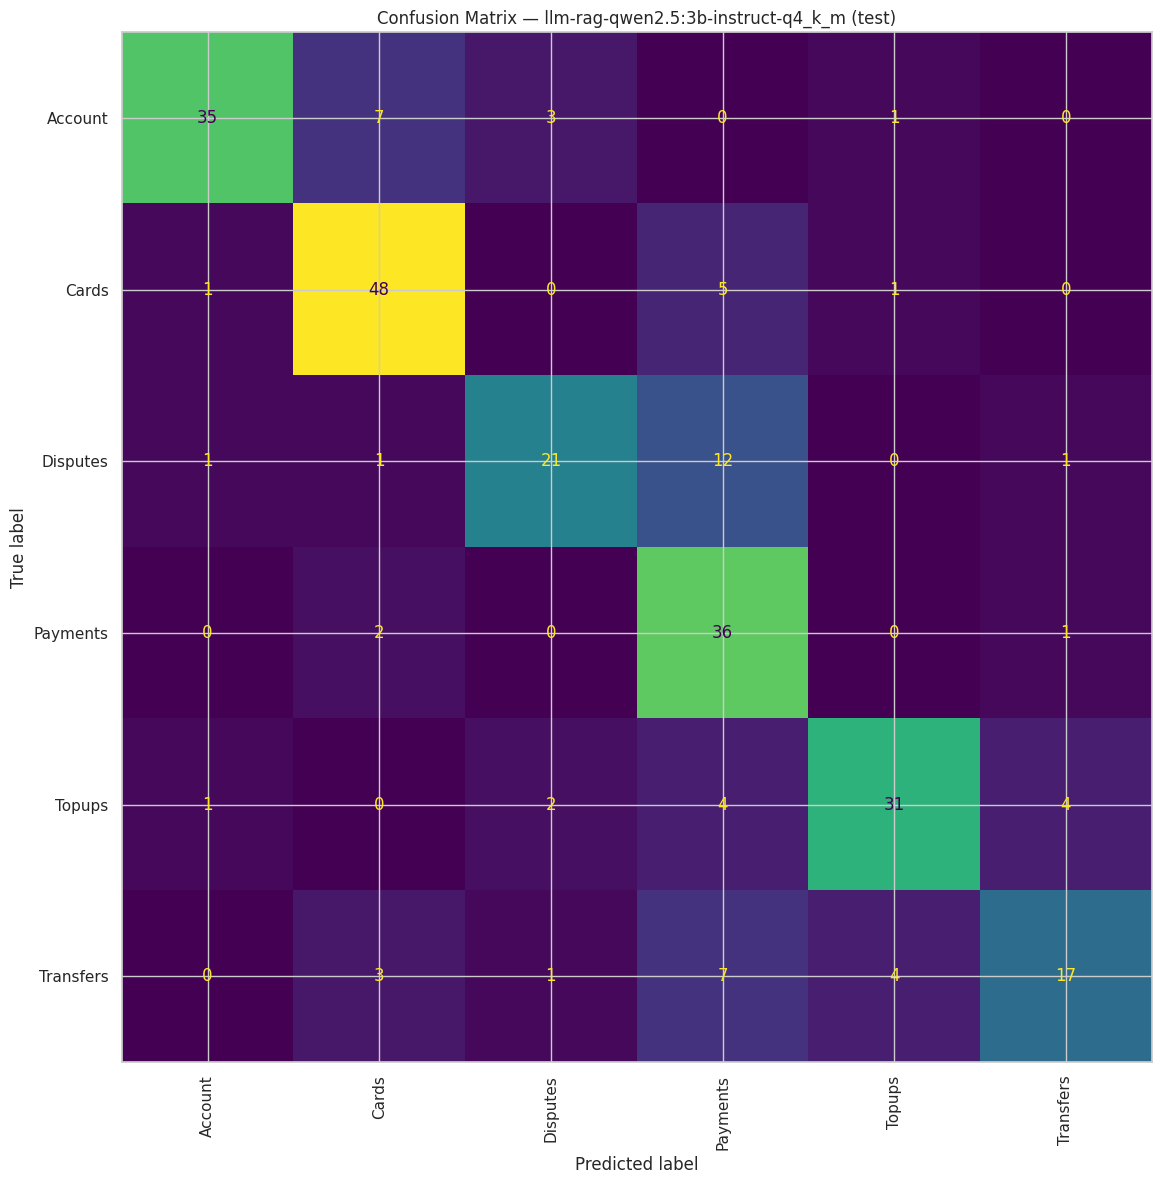

In [4]:
labels = sorted(set(dataset.y_test))

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay.from_predictions(
    dataset.y_test,
    y_test_pred,
    display_labels=labels,
    xticks_rotation='vertical',
    ax=ax,
    colorbar=False,
)
ax.set_title(f'Confusion Matrix — {BEST_EXPERIMENT} (test)')
plt.tight_layout()
plt.show()